# **1. Perkenalan Dataset**


## 1. Sumber Dataset

Dataset yang digunakan berasal dari CoinGecko API dan berisi data historis cryptocurrency untuk 50 koin kripto dengan kapitalisasi pasar terbesar (*Top 50 Crypto Coins by Market Capitalization*).

Dataset tersedia dalam format CSV, di mana setiap file merepresentasikan satu cryptocurrency. Data historis tersedia secara harian mulai dari 1 Januari 2015.

Kolom pada dataset meliputi:
- **date** : tanggal observasi data
- **price** : harga cryptocurrency pada tanggal tersebut
- **total_volume** : total volume transaksi harian
- **market_cap** : nilai kapitalisasi pasar dalam USD

Dataset ini dipilih karena sesuai untuk analisis data time series dan prediksi tren cryptocurrency.


## 2. Batasan Masalah

Koin yang digunakan untuk prediksi sementara hanya bitcoin

Data berasal dari https://www.kaggle.com/datasets/sudalairajkumar/cryptocurrency-historical-prices-coingecko?select=bitcoin.csv

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [6]:
csv_file_path = '../bitcoin_raw.csv'

df = pd.read_csv(csv_file_path)
display(df.head())

,date,price,total_volume,market_cap,coin_name
0,2015-01-01 00:00:00.000,313.992,4.699936e+07,4.293958e+09,bitcoin
1,2015-01-02 00:00:00.000,314.446,3.885591e+07,4.301448e+09,bitcoin
2,2015-01-03 00:00:00.000,286.572,1.187789e+08,3.921358e+09,bitcoin
3,2015-01-04 00:00:00.000,260.936,2.055001e+08,3.571640e+09,bitcoin
4,2015-01-05 00:00:00.000,273.220,1.550381e+08,3.740880e+09,bitcoin


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3373 entries, 0 to 3372
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          3373 non-null   object 
 1   price         3373 non-null   float64
 2   total_volume  3373 non-null   float64
 3   market_cap    3372 non-null   float64
 4   coin_name     3373 non-null   object 
dtypes: float64(3), object(2)
memory usage: 131.9+ KB


In [8]:
df.describe()

,price,total_volume,market_cap
count,3373.000000,3.373000e+03,3.372000e+03
mean,16010.058094,1.724184e+10,3.008013e+11
std,17194.074719,1.883256e+10,3.296922e+11
min,172.147900,1.823845e+07,2.362640e+09
25%,1280.986000,1.454057e+09,2.085192e+10
50%,8881.391704,1.237354e+10,1.583968e+11
75%,26848.239940,2.743276e+10,5.211950e+11
max,73097.767027,1.788941e+11,1.436631e+12


In [9]:
df.isnull().sum()

date            0
price           0
total_volume    0
market_cap      1
coin_name       0
dtype: int64

## Visualisasi data

Visualisasi fitur price, total volume, and market capitalization.

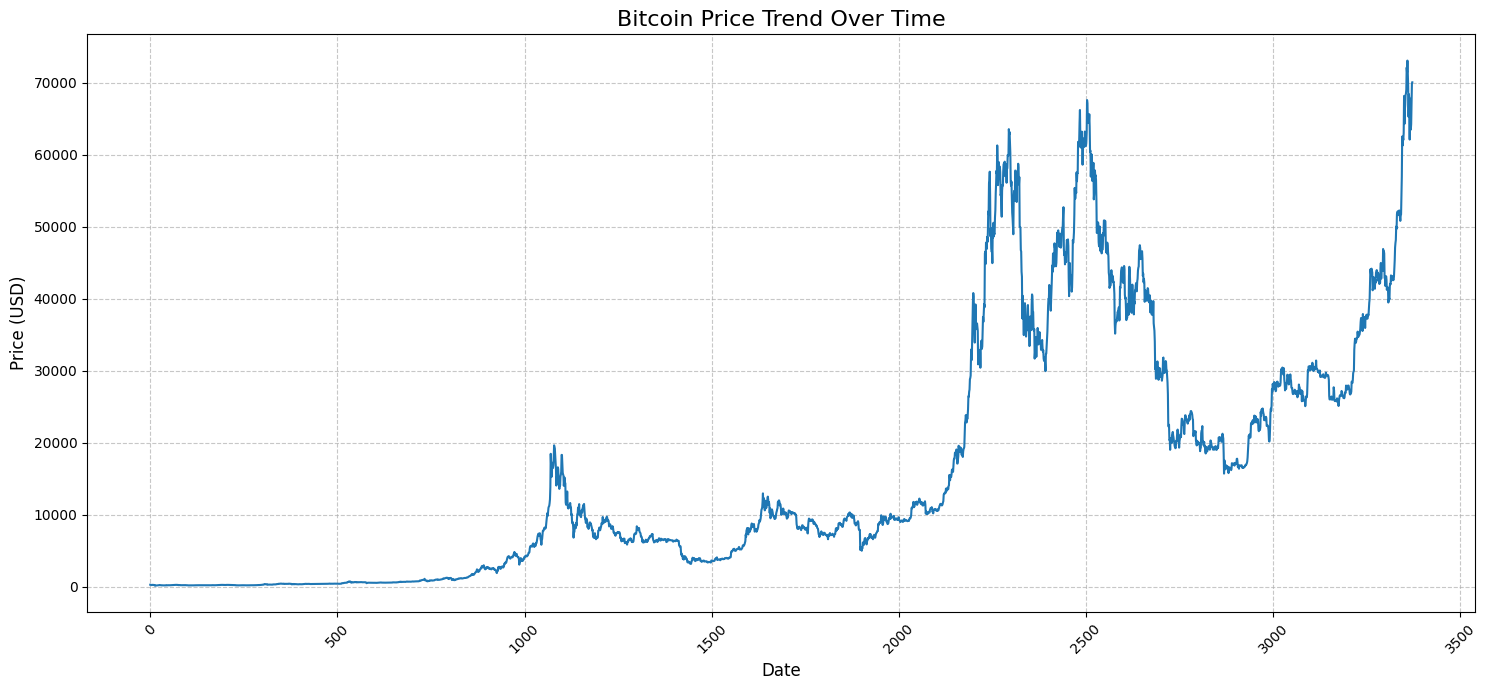

In [10]:
plt.figure(figsize=(15, 7))
sns.lineplot(x=df.index, y='price', data=df)
plt.title('Bitcoin Price Trend Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

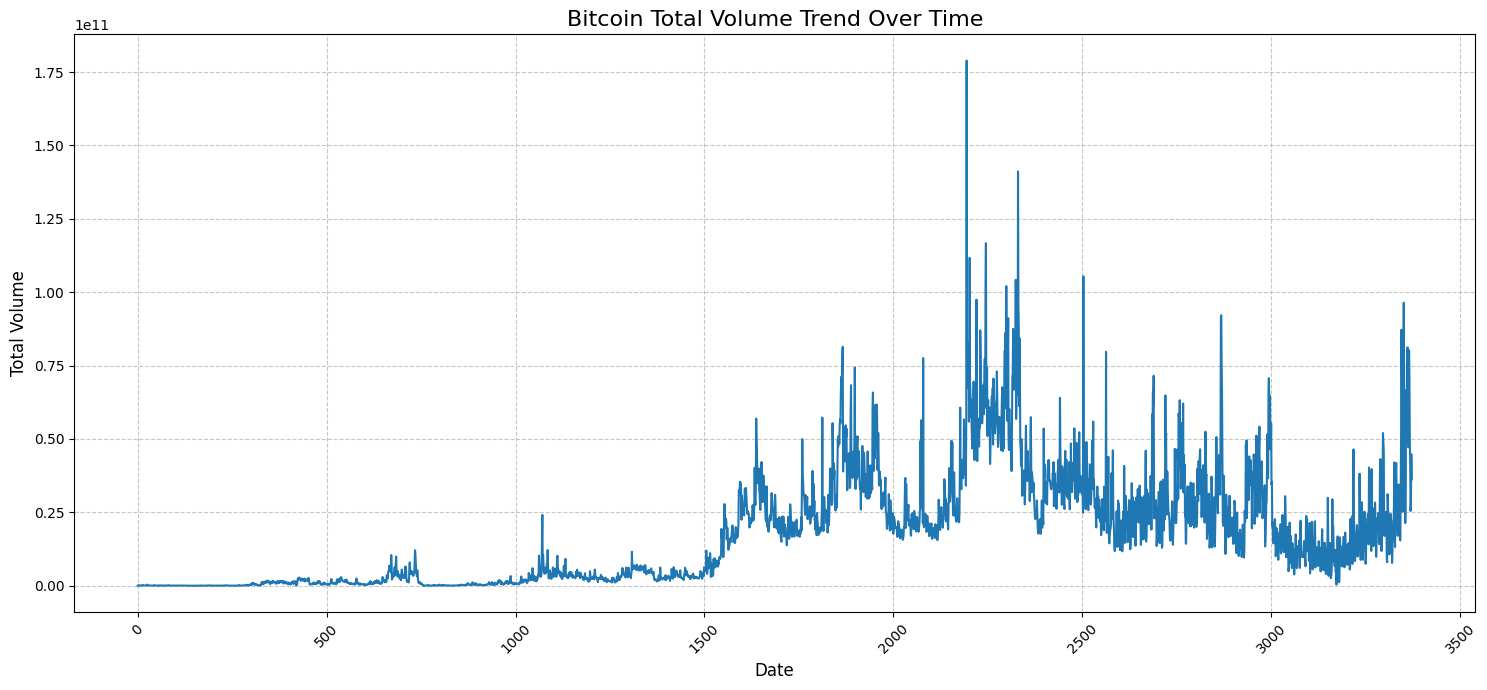

In [11]:
plt.figure(figsize=(15, 7))
sns.lineplot(x=df.index, y='total_volume', data=df)
plt.title('Bitcoin Total Volume Trend Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Volume', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

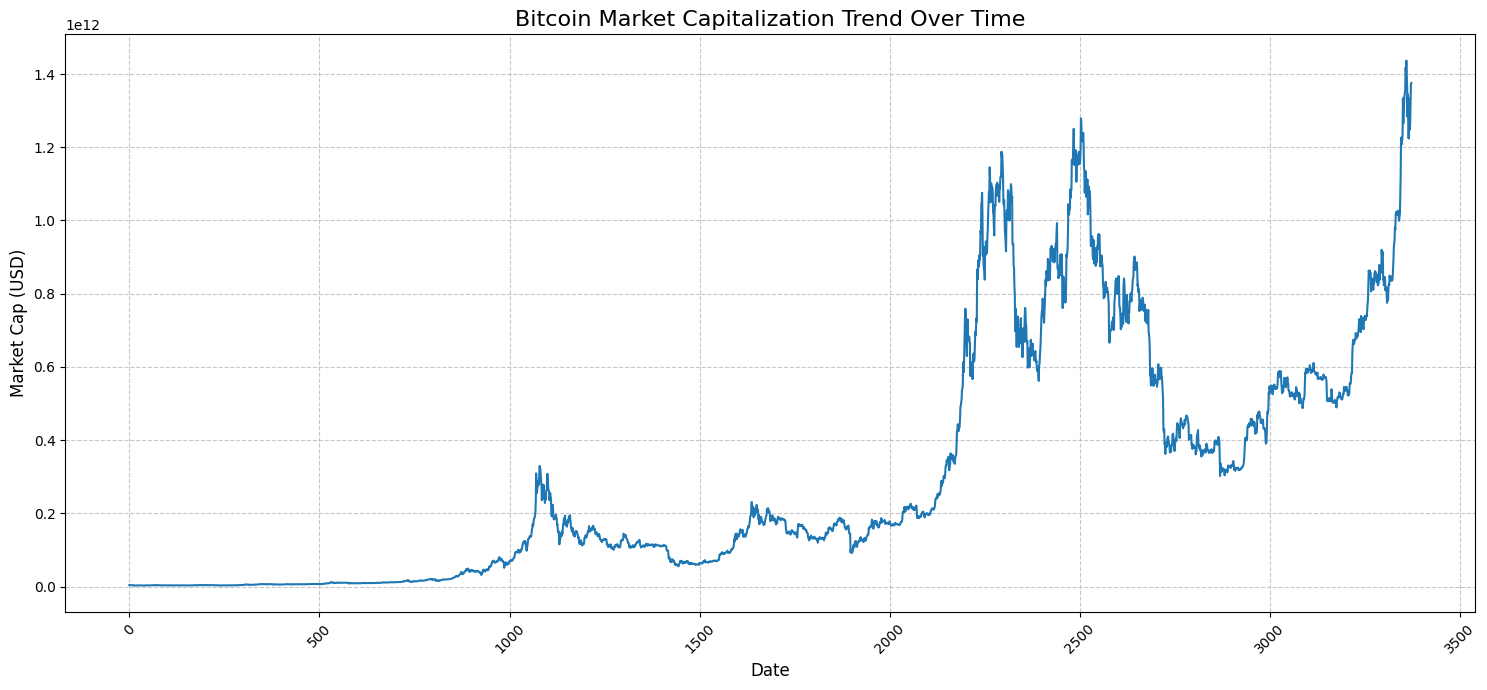

In [12]:
plt.figure(figsize=(15, 7))
sns.lineplot(x=df.index, y='market_cap', data=df)
plt.title('Bitcoin Market Capitalization Trend Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Market Cap (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# Mengonversi kolom 'date' ke tipe data datetime
df['date'] = pd.to_datetime(df['date'])

# Memeriksa kembali nilai yang hilang setelah konversi
print("\nMissing values after date conversion:")
print(df.isnull().sum())

# Memeriksa baris duplikat
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Mengisi nilai yang hilang pada kolom 'market_cap' dengan nilai periode sebelumnya dari kolom tersebut
df['market_cap'] = df['market_cap'].ffill()

# Memeriksa kembali nilai yang hilang setelah imputasi
print("\nMissing values after imputation:")
print(df.isnull().sum())

# Menampilkan info DataFrame setelah preprocessing dasar untuk verifikasi
print("\nDataFrame info after basic preprocessing:")
df.info()


Missing values after date conversion:
date            0
price           0
total_volume    0
market_cap      1
coin_name       0
dtype: int64

Number of duplicate rows:
0

Missing values after imputation:
date            0
price           0
total_volume    0
market_cap      0
coin_name       0
dtype: int64

DataFrame info after basic preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3373 entries, 0 to 3372
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          3373 non-null   datetime64[ns]
 1   price         3373 non-null   float64       
 2   total_volume  3373 non-null   float64       
 3   market_cap    3373 non-null   float64       
 4   coin_name     3373 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 131.9+ KB


In [14]:
# Ekstraksi fitur berbasis waktu
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

# Menghitung moving average untuk kolom 'price', 'total_volume', dan 'market_cap'
# Misalnya, 7-hari (mingguan) dan 30-hari (bulanan) moving average
window_sizes = [7, 30]
for window in window_sizes:
    df[f'price_ma_{window}d'] = df['price'].rolling(window=window).mean()
    df[f'total_volume_ma_{window}d'] = df['total_volume'].rolling(window=window).mean()
    df[f'market_cap_ma_{window}d'] = df['market_cap'].rolling(window=window).mean()

# Menampilkan 5 baris pertama DataFrame dengan fitur baru
print("DataFrame with new features (first 5 rows):")
display(df.head())

# Menampilkan informasi DataFrame untuk melihat kolom baru
print("\nDataFrame info after Feature Engineering:")
df.info()

DataFrame with new features (first 5 rows):


,date,price,total_volume,market_cap,coin_name,year,month,day,day_of_week,week_of_year,quarter,price_ma_7d,total_volume_ma_7d,market_cap_ma_7d,price_ma_30d,total_volume_ma_30d,market_cap_ma_30d
0,2015-01-01,313.992,4.699936e+07,4.293958e+09,bitcoin,2015,1,1,3,1,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,314.446,3.885591e+07,4.301448e+09,bitcoin,2015,1,2,4,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-03,286.572,1.187789e+08,3.921358e+09,bitcoin,2015,1,3,5,1,1,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-04,260.936,2.055001e+08,3.571640e+09,bitcoin,2015,1,4,6,1,1,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-05,273.220,1.550381e+08,3.740880e+09,bitcoin,2015,1,5,0,2,1,NaN,NaN,NaN,NaN,NaN,NaN



DataFrame info after Feature Engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3373 entries, 0 to 3372
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 3373 non-null   datetime64[ns]
 1   price                3373 non-null   float64       
 2   total_volume         3373 non-null   float64       
 3   market_cap           3373 non-null   float64       
 4   coin_name            3373 non-null   object        
 5   year                 3373 non-null   int32         
 6   month                3373 non-null   int32         
 7   day                  3373 non-null   int32         
 8   day_of_week          3373 non-null   int32         
 9   week_of_year         3373 non-null   int64         
 10  quarter              3373 non-null   int32         
 11  price_ma_7d          3367 non-null   float64       
 12  total_volume_ma_7d   3367 non-null   float64   

In [ ]:
if df is not None:
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
        df = df.sort_index()

    print('\nDataFrame head after date conversion and index setting:')
    display(df.head())

if df is not None:
    # Lag features = data sebelumnya
    for i in range(1, 4):
        df[f'price_lag_{i}'] = df['price'].shift(i)

    # Data rata2 bergerak sampai hari itu dengan periode 7 dan 30 hari.
    df['price_rolling_mean_7'] = df['price'].rolling(window=7).mean()
    df['price_rolling_mean_30'] = df['price'].rolling(window=30).mean()

    # Untuk data awal yang belum ada rolling data
    df.dropna(inplace=True)

    print('\nDataFrame head after feature engineering:')
    display(df.head())


DataFrame head after date conversion and index setting:


,price,total_volume,market_cap,coin_name,year,month,day,day_of_week,week_of_year,quarter,price_ma_7d,total_volume_ma_7d,market_cap_ma_7d,price_ma_30d,total_volume_ma_30d,market_cap_ma_30d
date,,,,,,,,,,,,,,,,
2015-01-01,313.992,4.699936e+07,4.293958e+09,bitcoin,2015,1,1,3,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-02,314.446,3.885591e+07,4.301448e+09,bitcoin,2015,1,2,4,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-03,286.572,1.187789e+08,3.921358e+09,bitcoin,2015,1,3,5,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-04,260.936,2.055001e+08,3.571640e+09,bitcoin,2015,1,4,6,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,273.220,1.550381e+08,3.740880e+09,bitcoin,2015,1,5,0,2,1,NaN,NaN,NaN,NaN,NaN,NaN



DataFrame head after feature engineering:


,price,total_volume,market_cap,coin_name,year,month,day,day_of_week,week_of_year,quarter,...,total_volume_ma_7d,market_cap_ma_7d,price_ma_30d,total_volume_ma_30d,market_cap_ma_30d,price_lag_1,price_lag_2,price_lag_3,price_rolling_mean_7,price_rolling_mean_30
date,,,,,,,,,,,,,,,,,,,,,
2015-01-31,218.0233,9.245920e+07,3.005342e+09,bitcoin,2015,1,31,5,5,1,...,1.970473e+08,3.367081e+09,248.621337,1.418051e+08,3.412761e+09,228.6354,232.532942,259.235600,244.521477,248.621337
2015-02-01,226.2697,1.008442e+08,3.119897e+09,bitcoin,2015,2,1,6,5,1,...,1.921774e+08,3.325135e+09,245.697260,1.436000e+08,3.373625e+09,218.0233,228.635400,232.532942,241.403435,245.697260
2015-02-02,240.0193,1.080438e+08,3.310466e+09,bitcoin,2015,2,2,0,6,1,...,1.872656e+08,3.299012e+09,243.216370,1.459062e+08,3.340593e+09,226.2697,218.023300,228.635400,239.429206,243.216370
2015-02-03,226.0119,1.357902e+08,3.117998e+09,bitcoin,2015,2,3,1,6,1,...,1.492705e+08,3.210964e+09,241.197700,1.464733e+08,3.313814e+09,240.0193,226.269700,218.023300,232.961163,241.197700
2015-02-04,225.3083,8.315551e+07,3.109176e+09,bitcoin,2015,2,4,2,6,1,...,1.125853e+08,3.145314e+09,240.010110,1.423951e+08,3.298398e+09,226.0119,240.019300,226.269700,228.114406,240.010110


In [ ]:
# Simpan DataFrame yang sudah diproses ke file CSV baru
output_csv_path = 'preprocessing/bitcoin.csv'
df.to_csv(output_csv_path, index=False)

print(f"Preprocessing selesai.")
print(f"Output saved to: {output_csv_path}")